# Actividad 1: Conceptos generales de redes neuronales
En esta actividad vamos a revisar algunos de los conceptos basicos de las redes neuronales, pero no por ello menos importantes.

El dataset a utilizar es Fashion MNIST, un problema sencillo con imágenes pequeñas de ropa, pero más interesante que el dataset de MNIST. Puedes consultar más información sobre el dataset en este enlace.

El código utilizado para contestar tiene que quedar claramente reflejado en el Notebook. Puedes crear nuevas cells si así lo deseas para estructurar tu código y sus salidas. A la hora de entregar el notebook, asegúrate de que los resultados de ejecutar tu código han quedado guardados (por ejemplo, a la hora de entrenar una red neuronal tiene que verse claramente un log de los resultados de cada epoch).

In [1]:
import tensorflow as tf
print(tf.__version__)

2.17.1


En primer lugar vamos a importar el dataset Fashion MNIST (recordad que este es uno de los dataset de entranamiento que estan guardados en keras) que es el que vamos a utilizar en esta actividad:

In [2]:
mnist = tf.keras.datasets.fashion_mnist

Llamar a **load_data** en este dataset nos dará dos conjuntos de dos listas, estos serán los valores de entrenamiento y prueba para los gráficos que contienen las prendas de vestir y sus etiquetas.

Nota: Aunque en esta actividad lo veis de esta forma, también lo vais a poder encontrar como 4 variables de esta forma: training_images, training_labels, test_images, test_labels = mnist.load_data()

In [3]:
(training_images, training_labels), (test_images, test_labels) = mnist.load_data()
print(training_images.shape)
print(training_labels.shape)
print(test_images.shape)
print(test_labels.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


Antes de continuar vamos a dar un vistazo a nuestro dataset, para ello vamos a ver una imagen de entrenamiento y su etiqueta o clase.

9
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   1   0   0  13  73   0   0   1   4   0   0   0   0   1   1   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3   0  36 136 127  62  54   0   0   0   1   3   4   0   0   3]
 [  0   0   0   0   0   0   0   0   0   0   0   0   6   0 102 204 176 134 144 123  23   0   0   0   0  12  10   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0 155 236 207 178 107 156 161 109  64  23  77 130  72  15]
 [  0   0   0   0   0   0   0   0   0   0   0   1   0  69 207 223 218 216 216 163 127 121 122 146 141  88 172  66]
 [  0   0   0   0   0   0   0   0   0   1   1   1   0 200 232 232 233 229 223 

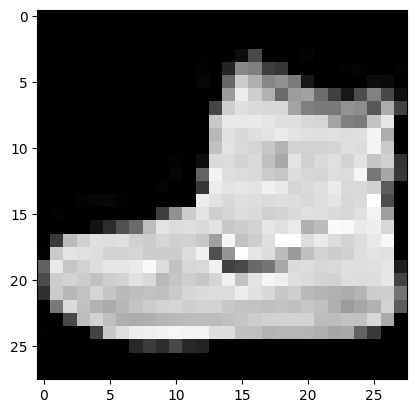

In [4]:
import numpy as np
np.set_printoptions(linewidth=200)
import matplotlib.pyplot as plt
plt.imshow(training_images[0], cmap="gray") # recordad que siempre es preferible trabajar en blanco y negro
#
print(training_labels[0])
print(training_images[0])

# print(training_labels.shape)


Habreis notado que todos los valores numericos están entre 0 y 255. Si estamos entrenando una red neuronal, una buena practica es transformar todos los valores entre 0 y 1, un proceso llamado "normalización" y afortunadamente en Python es fácil normalizar una lista. Lo puedes hacer de esta manera:

In [5]:
# vamos a dividir training_images en training y validate
X_valid, X_train = training_images[:12000], training_images[12000:]
y_valid, y_train = training_labels[:12000], training_labels[12000:]
print(f'Número de elementos para entrenar: {X_train.shape}')
print(f'Número de elementos para validar: {X_valid.shape}')
print(f'y_train: {y_train.shape}')
print(f'y_valid: {y_valid.shape}')



Número de elementos para entrenar: (48000, 28, 28)
Número de elementos para validar: (12000, 28, 28)
y_train: (48000,)
y_valid: (12000,)


In [6]:
X_train = X_train / 255.0
X_valid = X_valid / 255.0
test_images = test_images / 255.0

print(f'numero de imagenes en train: {training_images.shape[0]}')

numero de imagenes en train: 60000


Ahora vamos a definir el modelo, pero antes vamos a repasar algunos comandos y conceptos muy utiles:
* **Sequential**: Eso define una SECUENCIA de capas en la red neuronal
* **Dense**: Añade una capa de neuronas
* **Flatten**: ¿Recuerdas que las imágenes cómo eran las imagenes cuando las imprimiste para poder verlas? Un cuadrado, Flatten sólo toma ese cuadrado y lo convierte en un vector de una dimensión.

Cada capa de neuronas necesita una función de activación. Normalmente se usa la función relu en las capas intermedias y softmax en la ultima capa
* **Relu** significa que "Si X>0 devuelve X, si no, devuelve 0", así que lo que hace es pasar sólo valores 0 o mayores a la siguiente capa de la red.
* **Softmax** toma un conjunto de valores, y escoge el más grande.

 **Pregunta 1 (3.5 puntos)**. Utilizando Keras, y preparando los datos de X e y como fuera necesario, define y entrena una red neuronal que sea capaz de clasificar imágenes de Fashion MNIST con las siguientes características:

* Una hidden layer de tamaños 128, utilizando unidades sigmoid
Optimizador Adam.
* Durante el entrenamiento, la red tiene que mostrar resultados de loss y accuracy por cada epoch.
* La red debe entrenar durante 10 epochs y batch size de 64.
* La última capa debe de ser una capa softmax.
* Tu red tendría que ser capaz de superar fácilmente 80% de accuracy.

In [7]:
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Flatten(input_shape=(28, 28)))
model.add(tf.keras.layers.Dense(128, activation="sigmoid"))
model.add(tf.keras.layers.Dense(10, activation="softmax"))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:
model.compile(optimizer = 'adam',
              loss = 'sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [9]:
print(f'Número de elementos para entrenar: {y_train.shape}')
print(f'Número de elementos para validar: {y_valid.shape}')
trained_model = model.fit(X_train, y_train, epochs=10, batch_size=64, verbose=1)

Número de elementos para entrenar: (48000,)
Número de elementos para validar: (12000,)
Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7217 - loss: 0.8865
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8439 - loss: 0.4417
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8601 - loss: 0.3878
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8680 - loss: 0.3664
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8765 - loss: 0.3452
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8798 - loss: 0.3355
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8844 - loss: 0.3173
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8894 - loss: 0.3048
Epoch 9/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8924 - loss: 0.2950
Epoch 10/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8984 - loss: 0.2757


Para concluir el entrenamiento de la red neuronal, una buena practica es evaluar el modelo para ver si la precisión de entrenamiento es real

**pregunta 2 (0.5 puntos)**: evalua el modelo con las imagenes y etiquetas test.

In [10]:
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print(f"Test accuracy: {test_acc:.2f}")

313/313 - 0s - 2ms/step - accuracy: 0.8704 - loss: 0.3532
Test accuracy: 0.87


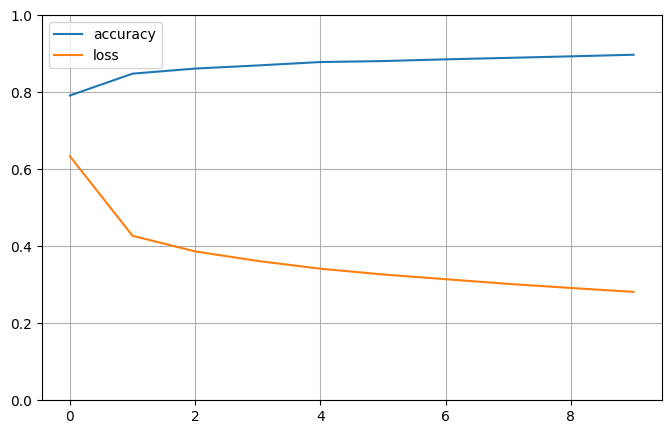

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

pd.DataFrame(trained_model.history).plot(figsize=(8,5))
plt.grid(True)
plt.gca().set_ylim(0,1)
plt.show()

Ahora vamos a explorar el código con una serie de ejercicios para alcanzar un grado de comprensión mayor sobre las redes neuronales y su entrenamiento.

# **Ejercicio 1: Funcionamiento de las predicción de la red neuronal**

Para este primer ejercicio sigue los siguientes pasos:

* Crea una variable llamada **classifications** para construir un clasificador para las imágenes de prueba, para ello puedes utilizar la función predict sobre el conjunto de test
* Imprime con la función print la primera entrada en las clasificaciones.

**pregunta 3.1 (0.25 puntos)**, el resultado al imprimirlo es un vector de números,
* ¿Por qué crees que ocurre esto, y qué representa este vector de números?

**Es un vector que representa la probabilidad que asigna el modelo a cada una de las 10 clases de nuestro dataset, cada una de las posisiones del vector representa esa probabilidad.**

**pregunta 3.2 (0.25 puntos)**
* ¿Cúal es la clase de la primera entrada#  de la variable **classifications**? La respuesta puede ser un número o su etiqueta/clase equivalente.

**La respuesta de la primera entrada es 9, coincidiendo con la primera entrada de test_labels**

In [23]:
classifications = model.predict(test_images)
print(classifications[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
[6.7739875e-06 2.2085057e-07 1.0966631e-06 1.0007726e-05 1.6544431e-05 2.6935650e-02 1.9685334e-05 3.4423437e-02 4.5410363e-04 9.3813229e-01]


In [24]:
import numpy as np
classes = np.argmax(classifications, axis = 1)
print(f'Predict {classes[0]} True label {test_labels[0]}')

Predict 9 True label 9


In [27]:
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]
predicted_label = class_names[classes[0]]
true_label = class_names[test_labels[0]]

print(f'Predicted: {predicted_label}, True label: {true_label}')

Predicted: Ankle boot, True label: Ankle boot


# **Ejercicio 2: Impacto variar el número de neuronas en las capas ocultas**

En este ejercicio vamos a experimentar con nuestra red neuronal cambiando el numero de neuronas por 512 y por 1024. Para ello, utiliza la red neuronal de la pregunta 1, y su capa oculta cambia las 128 neuronas:

* **pregunta 4.1 (0.25 puntos)**: 512 neuronas en la capa oculta
* **pregunta 4.2 (0.25 puntos)**:1024 neuronas en la capa oculta

y entrena la red en ambos casos.

**pregunta 4.3 (0.5 puntos)**: ¿Cual es el impacto que tiene la red neuronal?

/usr/local/lib/python3.10/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.7501 - loss: 0.7349
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8482 - loss: 0.4269
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8614 - loss: 0.3822
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8725 - loss: 0.3484
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8779 - loss: 0.3342
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.8854 - loss: 0.3172
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.8875 - loss: 0.3023
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8967 - loss: 0.2820
Epoch 9/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.9019 - loss: 0.2669
Epoch 10/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9062 - loss: 0.2538
313/313 - 1s - 2ms/step - accuracy: 0.8778 - loss: 0.3417
Test accuracy: 0.88


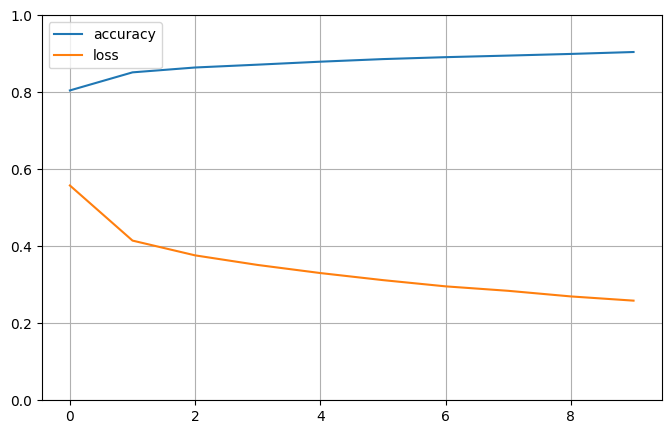

In [ ]:
model_512 = tf.keras.models.Sequential()
model_512.add(tf.keras.layers.Flatten(input_shape=(28, 28)))
model_512.add(tf.keras.layers.Dense(512, activation="sigmoid"))
model_512.add(tf.keras.layers.Dense(10, activation="softmax"))

model_512.compile(optimizer = 'adam',
              loss = 'sparse_categorical_crossentropy',
              metrics=['accuracy'])

trained_model_512 = model_512.fit(X_train, y_train, epochs=10, batch_size=64, verbose=1)

test_loss, test_acc = model_512.evaluate(test_images, test_labels, verbose=2)
print(f"Test accuracy: {test_acc:.2f}")

pd.DataFrame(trained_model_512.history).plot(figsize=(8,5))
plt.grid(True)
plt.gca().set_ylim(0,1)
plt.show()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.7561 - loss: 0.6949
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.8506 - loss: 0.4207
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 21s 16ms/step - accuracy: 0.8639 - loss: 0.3738
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - accuracy: 0.8720 - loss: 0.3519
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - accuracy: 0.8825 - loss: 0.3246
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.8842 - loss: 0.3135
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.8927 - loss: 0.2946
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.8962 - loss: 0.2823
Epoch 9/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.8993 - loss: 0.2668
Epoch 10/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - accuracy: 0.9078 - loss: 0.2483
313/313 - 1s - 3ms/step - accuracy: 0.8735 - loss: 0.3591
Test accuracy: 0.87


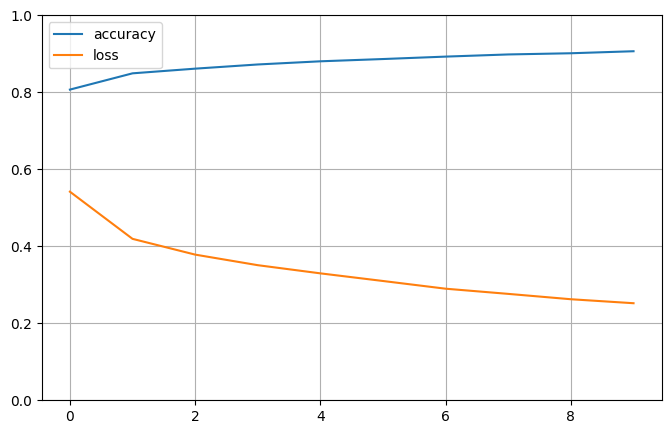

In [ ]:
model_1024 = tf.keras.models.Sequential()
model_1024.add(tf.keras.layers.Flatten(input_shape=(28, 28)))
model_1024.add(tf.keras.layers.Dense(1024, activation="sigmoid"))
model_1024.add(tf.keras.layers.Dense(10, activation="softmax"))

model_1024.compile(optimizer = 'adam',
              loss = 'sparse_categorical_crossentropy',
              metrics=['accuracy'])

trained_model_1024 = model_1024.fit(X_train, y_train, epochs=10, batch_size=64, verbose=1)

test_loss, test_acc = model_1024.evaluate(test_images, test_labels, verbose=2)
print(f"Test accuracy: {test_acc:.2f}")

pd.DataFrame(trained_model_1024.history).plot(figsize=(8,5))
plt.grid(True)
plt.gca().set_ylim(0,1)
plt.show()

Tu respuesta a la pregunta 4.3 aquí:

No hubo una mejora sustancial en ninguno de los modelos con mas neuronas en la capa oculta, ya que la unica mejora que hubo fue en la red neuronal con 512 neuronas en la capa oculta y fue de solo un 1%



Si ahora entrenais el modelo de esta forma (con 512 y 1024 neuronas en la capa oculta) y volveis a ejecutar el predictor guardado en la variable **classifications**, escribir el código del clasificador del ejercicio 1 de nuevo e imprimid el primer objeto guardado en la variable classifications.

**pregunta 5.1 (0.25 puntos)**:

* ¿En que clase esta clasificado ahora la primera prenda de vestir de la variable classifications?

**pregunta 5.1 (0.25 puntos)**:

* ¿Porque crees que ha ocurrido esto?

In [ ]:
classifications_512 = model_512.predict(test_images)
print(classifications_512[0])

classes = np.argmax(classifications_512, axis = 1)
print(f'Predict {classes[0]} True label {test_labels[0]}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[6.9162513e-07 9.4999191e-09 6.2382405e-08 5.9410269e-07 7.1691449e-07 2.3970477e-02 2.3330217e-06 9.6423710e-03 1.7781740e-05 9.6636504e-01]
Predict 9 True label 9


Tu respuesta a la pregunta 5.1 aquí:

**la respuesta sigue siendo en la clase 9**

Tu respuesta a la pregunta 5.1 aquí:

**Dado que el accuracy es practicamente el mismo en estos ultimos dos modelos, y sigue siendo un buen modelo, sigue haciendo buenas predicciones**

# **Ejercicio 3: ¿por qué es tan importante la capa Flatten?**

En este ejercicio vamos a ver que ocurre cuando quitamos la capa flatten, para ello, escribe la red neuronal de la pregunta 1 y no pongas la capa Flatten.

**pregunta 6 (0.5 puntos):** ¿puedes explicar porque da el error que da?



In [ ]:
model_without_flatten = tf.keras.models.Sequential()
model_without_flatten.add(tf.keras.layers.Dense(784, activation="sigmoid"))
model_without_flatten.add(tf.keras.layers.Dense(10, activation="softmax"))

model_without_flatten.compile(optimizer = 'adam',
              loss = 'sparse_categorical_crossentropy',
              metrics=['accuracy'])

trained_model_without_flatten = model_without_flatten.fit(X_train, y_train, epochs=10, batch_size=64, verbose=1)

test_loss, test_acc = model_without_flatten.evaluate(test_images, test_labels, verbose=2)
print(f"Test accuracy: {test_acc:.2f}")

pd.DataFrame(trained_model_without_flatten.history).plot(figsize=(8,5))
plt.grid(True)
plt.gca().set_ylim(0,1)
plt.show()

Epoch 1/10


ValueError: Argument `output` must have rank (ndim) `target.ndim - 1`. Received: target.shape=(64,), output.shape=(64, 28, 10)

Tu respuesta a la pregunta 6 aquí:

**EL codigo falla ya que esta recibiendo en la entrada una matriz en lugar de un vector o un array de solo una dimension, la capa flatten lo que hace es 'aplanar' la matriz al array que se necesita para el entrenamiento de la red neuronal.**

# **Ejercicio 4: Número de neuronas de la capa de salida**
Considerad la capa final, la de salida de la red neuronal de la pregunta 1.

**pregunta 7.1 (0.25 puntos)**: ¿Por qué son 10 las neuronas de la última capa?

**pregunta 7.2 (0.25 puntos)**: ¿Qué pasaría si tuvieras una cantidad diferente a 10?

Por ejemplo, intenta entrenar la red con 5, para ello utiliza la red neuronal de la pregunta 1 y cambia a 5 el número de neuronas en la última capa.

/usr/local/lib/python3.10/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7111 - loss: 0.9286
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8403 - loss: 0.4457
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8562 - loss: 0.3991
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8669 - loss: 0.3665
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8742 - loss: 0.3437
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8792 - loss: 0.3300
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8855 - loss: 0.3184
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8897 - loss: 0.3024
Epoch 9/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8956 - loss: 0.2932
Epoch 10/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8938 - loss: 0.2877
313/313 - 1s - 2ms/step - accuracy: 0.8734 - loss: 0.3536
Test accuracy: 0.87


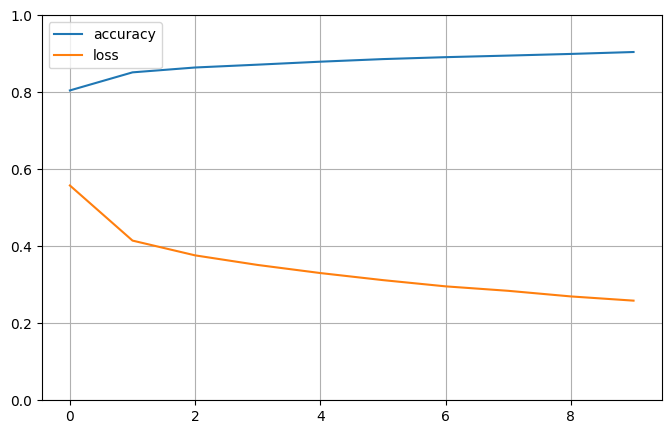

In [ ]:
model_2 = tf.keras.models.Sequential()
model_2.add(tf.keras.layers.Flatten(input_shape=(28, 28)))
model_2.add(tf.keras.layers.Dense(128, activation="sigmoid"))
model_2.add(tf.keras.layers.Dense(15, activation="softmax"))

model_2.compile(optimizer = 'adam',
              loss = 'sparse_categorical_crossentropy',
              metrics=['accuracy'])

trained_model_2 = model_2.fit(X_train, y_train, epochs=10, batch_size=64, verbose=1)

test_loss, test_acc = model_2.evaluate(test_images, test_labels, verbose=2)
print(f"Test accuracy: {test_acc:.2f}")

pd.DataFrame(trained_model_512.history).plot(figsize=(8,5))
plt.grid(True)
plt.gca().set_ylim(0,1)
plt.show()

In [ ]:
classifications_2 = model_2.predict(test_images)
print(classifications_2[0])

classes = np.argmax(classifications_2, axis = 1)
print(f'Predict {classes[0]} True label {test_labels[0]}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[6.8464260e-07 4.4414090e-08 5.3826483e-07 1.0969538e-06 3.5035266e-06 1.2104801e-02 4.5996412e-06 1.5330611e-02 1.1139703e-04 9.7244173e-01 3.3701428e-07 2.2429508e-07 4.7563287e-08 2.2734127e-07
 6.8289204e-08]
Predict 9 True label 9


Tu respuestas a la pregunta 7.1 aquí:

**La capa de salida tiene 10 neuronas porque son todas las categorias que tiene el dataset**

Tu respuestas a la pregunta 7.2 aquí:

**Si cambiamos el numero de neuronas puede que falla si el numero de neuronas de salida es menor al numero de clases que tiene el dataset. Si el numero de neuronas de salida es mayor no va a fallar el codigo pero tampoco veremos una mejora en el accuracy de nuestro modelo.**



# Ejercicio 5: Aumento de epoch y su efecto en la red neuronal
En este ejercicio vamos a ver el impacto de aumentar los epoch en el entrenamiento. Usando la red neuronal de la pregunta 1:

**pregunta 8.1 (0.20 puntos)**
* Intentad 15 epoch para su entrenamiento, probablemente obtendras un modelo con una pérdida mucho mejor que el que tiene 5.

**pregunta 8.2 (0.20 puntos)**
* Intenta ahora con 30 epoch para su entrenamiento, podrás ver que el valor de la pérdida deja de disminuir, y a veces aumenta.

**pregunta 8.3 (0.60 puntos)**
* ¿Porque que piensas que ocurre esto? Explica tu respuesta y da el nombre de este efecto si lo conoces.

/usr/local/lib/python3.10/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7114 - loss: 0.9405
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8421 - loss: 0.4449
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8578 - loss: 0.3951
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8651 - loss: 0.3710
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8733 - loss: 0.3494
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8794 - loss: 0.3320
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8852 - loss: 0.3173
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.8896 - loss: 0.3052
Epoch 9/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8934 - loss: 0.2938
Epoch 10/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8981 - loss: 0.2819
Epoch 11/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8999 - loss: 0.2745
Epoch 12/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step

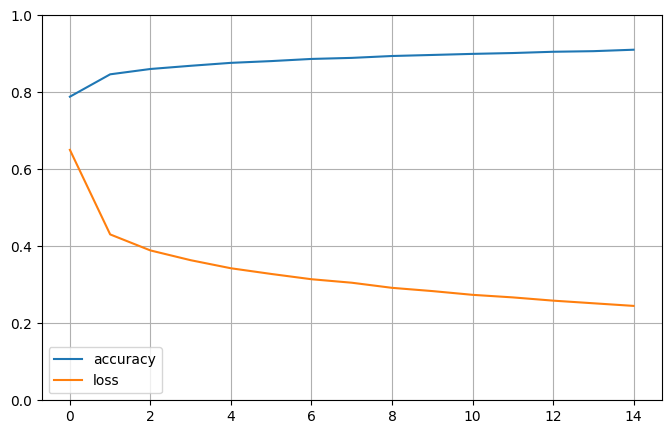

In [ ]:
model_15_epochs = tf.keras.models.Sequential()
model_15_epochs.add(tf.keras.layers.Flatten(input_shape=(28, 28)))
model_15_epochs.add(tf.keras.layers.Dense(128, activation="sigmoid"))
model_15_epochs.add(tf.keras.layers.Dense(15, activation="softmax"))

model_15_epochs.compile(optimizer = 'adam',
              loss = 'sparse_categorical_crossentropy',
              metrics=['accuracy'])

trained_model_15_epoch = model_15_epochs.fit(X_train, y_train, epochs=15, batch_size=64, verbose=1)

test_loss, test_acc = model_15_epochs.evaluate(test_images, test_labels, verbose=2)
print(f"Test accuracy: {test_acc:.2f}")

pd.DataFrame(trained_model_15_epoch.history).plot(figsize=(8,5))
plt.grid(True)
plt.gca().set_ylim(0,1)
plt.show()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7214 - loss: 0.9236
Epoch 2/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8453 - loss: 0.4381
Epoch 3/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8589 - loss: 0.3953
Epoch 4/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8711 - loss: 0.3620
Epoch 5/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8755 - loss: 0.3456
Epoch 6/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8789 - loss: 0.3276
Epoch 7/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8829 - loss: 0.3215
Epoch 8/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8893 - loss: 0.3043
Epoch 9/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8938 - loss: 0.2926
Epoch 10/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8969 - loss: 0.2808
Epoch 11/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9002 - loss: 0.2719
Epoch 12/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step

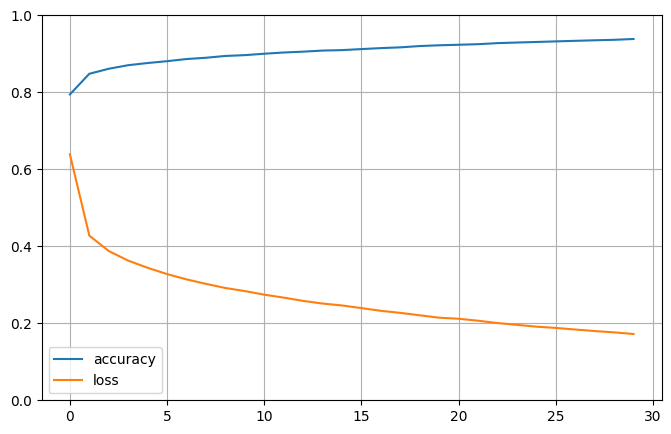

In [ ]:
model_30_epochs = tf.keras.models.Sequential()
model_30_epochs.add(tf.keras.layers.Flatten(input_shape=(28, 28)))
model_30_epochs.add(tf.keras.layers.Dense(128, activation="sigmoid"))
model_30_epochs.add(tf.keras.layers.Dense(15, activation="softmax"))

model_30_epochs.compile(optimizer = 'adam',
              loss = 'sparse_categorical_crossentropy',
              metrics=['accuracy'])

trained_model_30_epoch = model_30_epochs.fit(X_train, y_train, epochs=30, batch_size=64, verbose=1)

test_loss, test_acc = model_30_epochs.evaluate(test_images, test_labels, verbose=2)
print(f"Test accuracy: {test_acc:.2f}")

pd.DataFrame(trained_model_30_epoch.history).plot(figsize=(8,5))
plt.grid(True)
plt.gca().set_ylim(0,1)
plt.show()

Tu respuesta a la pregunta 8.3 aquí:

**Lo que ocurre es que el accuracy mejora, pero llega un punto en el que las mejoras son minimas entre cada epoca. Esto es porque el ajuste en los pesos de cada neurona es menor porque el modelo ha aprendido bien dentro de su capacidad y se equivoca menos y su capacidad de generalizar va llegando a su limite. Llegados a este punto el modelo no va a mejorar mucho y seria un gasto de recursos agregar mas epocas, este fenomeno se llama diminishing returns**

# Ejercicio 6: Early stop
En el ejercicio anterior, cuando entrenabas con epoch extras, tenías un problema en el que tu pérdida podía cambiar. Puede que te haya llevado un poco de tiempo esperar a que el entrenamiento lo hiciera,  y puede que hayas pensado "¿no estaría bien si pudiera parar el entrenamiento cuando alcance un valor deseado?", es decir, una precisión del 85% podría ser suficiente para ti, y si alcanzas eso después de 3 epoch, ¿por qué sentarte a esperar a que termine muchas más épocas? Como cualquier otro programa existen formas de parar la ejecución

A partir del ejemplo de código que

 se da, hacer una nueva función que tenga en cuenta la perdida (loss) y que pueda parar el código para
evitar que ocurra el efeto secundario que vimos en el ejercicio 5.

In [30]:
### Ejemplo de código

class myCallback(tf.keras.callbacks.Callback):
      def on_epoch_end(self, epoch, logs={}):
        if(logs.get('accuracy')> 0.85):
              print("\nAlcanzado el 85% de precisión, se cancela el entrenamiento!!")
              self.model.stop_training = True

**Pregunta 9 (2 puntos)**: Completa el siguiente código con una clase callback que una vez alcanzado el 40% de perdida detenga el entrenamiento.

In [32]:
class myCallbackStop(tf.keras.callbacks.Callback):
      def on_epoch_end(self, epoch, logs={}):
        if(logs.get('loss')< 0.40):
              print("\nAlcanzado el 40% de perdida, se cancela el entrenamiento!!")
              self.model.stop_training = True

callbacks = myCallback()
callbacks_stop = myCallbackStop()

model_stop = tf.keras.models.Sequential([tf.keras.layers.Flatten(input_shape=(28, 28)),
                                    tf.keras.layers.Dense(512, activation=tf.nn.relu),
                                    tf.keras.layers.Dense(10, activation=tf.nn.softmax)])

model_stop.compile(optimizer = 'adam',
              loss = 'sparse_categorical_crossentropy',
              metrics=['accuracy'])

model_stop.fit(X_train, y_train, epochs=50, callbacks=[callbacks_stop])

Epoch 1/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.7853 - loss: 0.6106
Epoch 2/50
1492/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8612 - loss: 0.3809
Alcanzado el 40% de perdida, se cancela el entrenamiento!!
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8612 - loss: 0.3808
